# Análises: Desafio Técnico Manchester Investimentos

Base tratada em `01_tratamento.py`. Aqui respondo as 5 perguntas de negócio
do desafio, cada uma com o raciocínio, o código e os gráficos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_parquet("../data/vendas_tratado.parquet")
df.shape

(499449, 14)

## Pergunta 1: Perfil demográfico dos clientes

Importante: idade e região são atributos do **cliente**, não da transação.
Um mesmo cliente aparece em várias linhas (em média ~6 compras). Verifiquei
na Fase 1 do diagnóstico que idade e estado são consistentes por cliente
(nenhum cliente tem mais de um valor registrado), então aqui eu agrego por
`cliente` antes de descrever a distribuição, para não contar a mesma pessoa
várias vezes e enviesar a análise pelo volume de compras dela.

In [2]:
clientes = df.dropna(subset=["cliente", "idade", "estado"]).drop_duplicates("cliente")
print(f"clientes únicos analisados: {len(clientes)}")
print(clientes["idade"].describe())

clientes únicos analisados: 79838
count   79,838.00
mean        39.18
std         11.56
min         18.00
25%         31.00
50%         39.00
75%         47.00
max         80.00
Name: idade, dtype: float64


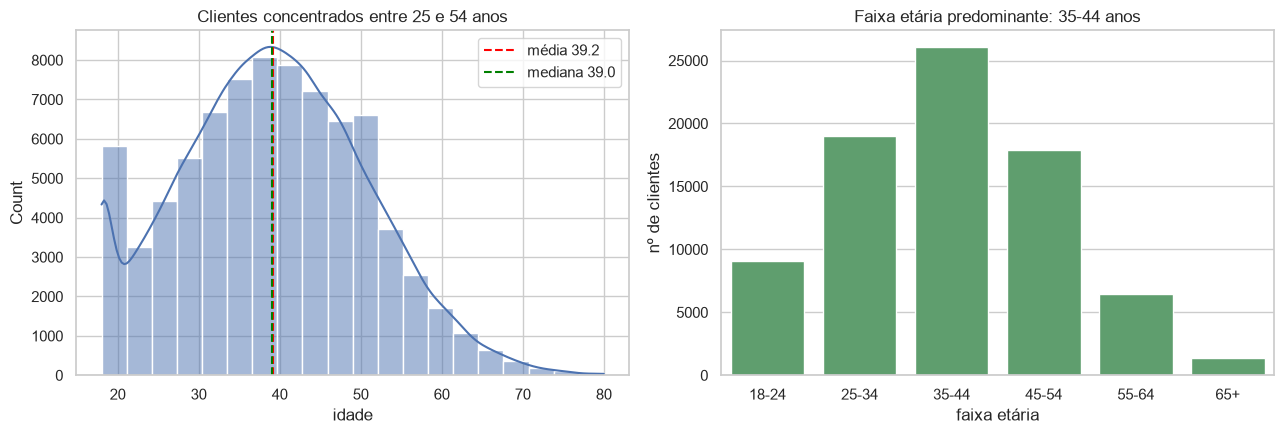

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(clientes["idade"], bins=20, kde=True, ax=axes[0], color="#4C72B0")
axes[0].axvline(clientes["idade"].mean(), color="red", linestyle="--", label=f"média {clientes['idade'].mean():.1f}")
axes[0].axvline(clientes["idade"].median(), color="green", linestyle="--", label=f"mediana {clientes['idade'].median():.1f}")
axes[0].set_title("Clientes concentrados entre 25 e 54 anos")
axes[0].set_xlabel("idade")
axes[0].legend()

faixa_counts = clientes["faixa_etaria"].value_counts().sort_index()
sns.barplot(x=faixa_counts.index, y=faixa_counts.values, ax=axes[1], color="#55A868")
axes[1].set_title("Faixa etária predominante: 35-44 anos")
axes[1].set_xlabel("faixa etária")
axes[1].set_ylabel("nº de clientes")

plt.tight_layout()
plt.savefig("../assets/01_perfil_idade.png", dpi=120)
plt.show()

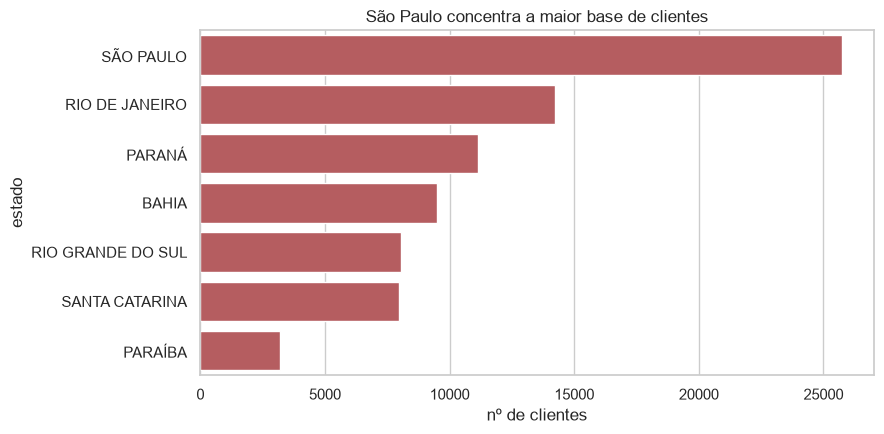

In [4]:
estado_counts = clientes["estado"].value_counts()
plt.figure(figsize=(9, 4.5))
sns.barplot(x=estado_counts.values, y=estado_counts.index, color="#C44E52")
plt.title("São Paulo concentra a maior base de clientes")
plt.xlabel("nº de clientes")
plt.tight_layout()
plt.savefig("../assets/02_perfil_estado.png", dpi=120)
plt.show()

**Insight:** o perfil predominante é adulto de meia-idade (35-44 anos, média
geral de ~39 anos), concentrado em São Paulo e no eixo Sul/Sudeste. Faixas
acima de 65 anos são uma fatia pequena da base de clientes.

## Pergunta 2: Performance por categoria de produto

Aqui a unidade de análise é a transação (linha), não o cliente: cada linha
já representa uma venda de uma categoria específica, então não preciso
deduplicar por cliente como na pergunta 1.

In [5]:
cat_perf = df.groupby("categoria").agg(
    faturamento_total=("faturamento", "sum"),
    volume_total=("quantidade_vendida", "sum"),
    qtd_transacoes=("faturamento", "count"),
    ticket_medio=("faturamento", "mean"),
).sort_values("faturamento_total", ascending=False)

cat_perf["pct_faturamento"] = cat_perf["faturamento_total"] / cat_perf["faturamento_total"].sum() * 100
cat_perf["pct_acumulado"] = cat_perf["pct_faturamento"].cumsum()
cat_perf

,faturamento_total,volume_total,qtd_transacoes,ticket_medio,pct_faturamento,pct_acumulado
categoria,,,,,,
JARDINAGEM,1001667550,20033351,99694,"10,047.42",33.25,33.25
UTILIDADES DOMÉSTICAS,917232975,20382955,100356,"9,139.79",30.44,63.69
LIMPEZA,484641300,16154710,99935,"4,849.57",16.09,79.78
MANGUEIRAS,446897940,29793196,99502,"4,491.35",14.83,94.61
MAQUINA DE CORTAR GRAMA,162428125,6497125,99962,"1,624.90",5.39,100.00


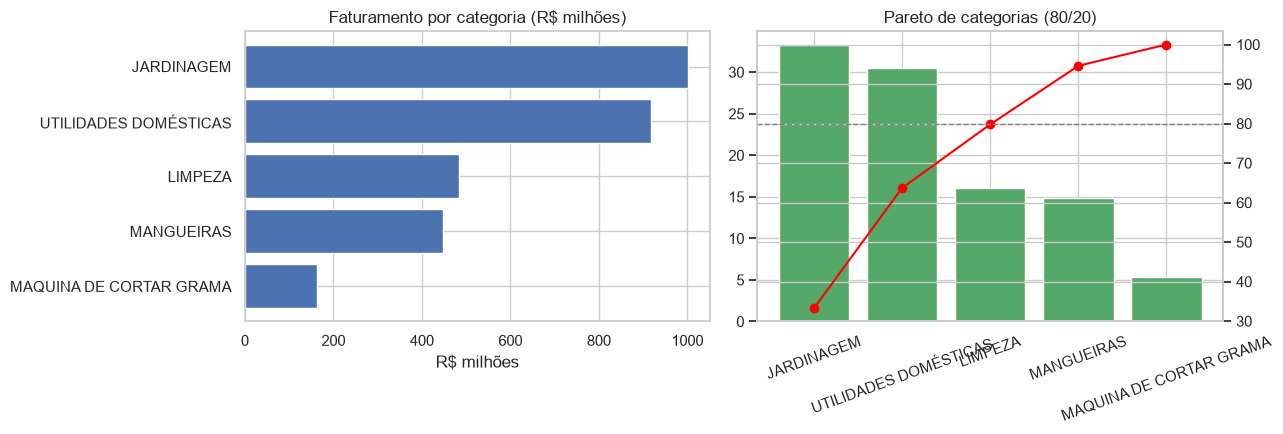

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

cat_perf_sorted = cat_perf.sort_values("faturamento_total")
axes[0].barh(cat_perf_sorted.index, cat_perf_sorted["faturamento_total"] / 1e6, color="#4C72B0")
axes[0].set_title("Faturamento por categoria (R$ milhões)")
axes[0].set_xlabel("R$ milhões")

order = cat_perf.index
ax2 = axes[1]
ax2.bar(order, cat_perf.loc[order, "pct_faturamento"], color="#55A868", label="% do faturamento")
ax2b = ax2.twinx()
ax2b.plot(order, cat_perf.loc[order, "pct_acumulado"], color="red", marker="o", label="% acumulado")
ax2b.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_title("Pareto de categorias (80/20)")
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../assets/03_categoria_pareto.png", dpi=120)
plt.show()

**Insight:** o volume de transações é quase idêntico entre as 5 categorias
(todas em torno de 20% do total, ~100 mil transações cada), mas o
**faturamento é concentrado**: Jardinagem (33,2%) e Utilidades Domésticas
(30,4%) somam sozinhas 63,7% da receita, e as 3 primeiras categorias
(+ Limpeza) já somam 79,8%, próximo do padrão Pareto 80/20 mesmo sem ser
literal (aqui é ~60% das categorias gerando ~80% da receita). Essa
concentração vem do preço unitário: Jardinagem (R$ 50) e Utilidades
Domésticas (R$ 45) têm os maiores tickets médios (R$ 10.047 e R$ 9.140),
enquanto Máquina de Cortar Grama, apesar de vender tanto quanto as outras em
volume de transações, tem o menor preço unitário (R$ 25 na base, mas o
menor ticket médio da base) e responde por só 5,4% do faturamento.

**Recomendação:** o esforço comercial não deveria se guiar por volume de
transações (que é uniforme entre categorias), e sim por ticket médio.
Jardinagem e Utilidades Domésticas merecem prioridade em estoque e
visibilidade por serem as que mais geram receita por venda.

## Pergunta 3: Sazonalidade

A base cobre 5 anos completos (2021-2025), então dá pra comparar mês a mês
sem viés de ano incompleto.

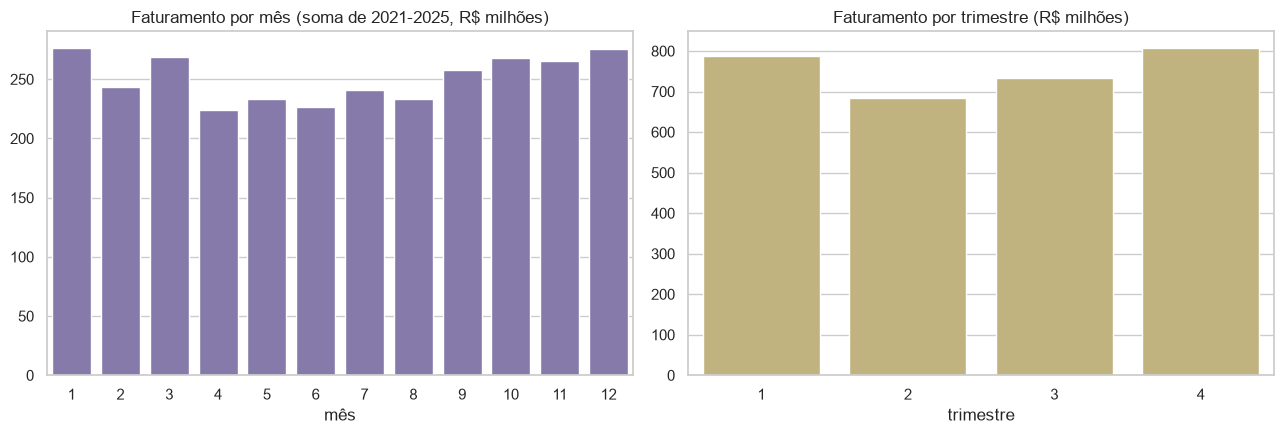

(np.int32(1), np.int32(4))

In [7]:
mes_perf = df.groupby("mes")["faturamento"].sum()
trimestre_perf = df.groupby("trimestre")["faturamento"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=mes_perf.index, y=mes_perf.values / 1e6, ax=axes[0], color="#8172B2")
axes[0].set_title("Faturamento por mês (soma de 2021-2025, R$ milhões)")
axes[0].set_xlabel("mês")

sns.barplot(x=trimestre_perf.index, y=trimestre_perf.values / 1e6, ax=axes[1], color="#CCB974")
axes[1].set_title("Faturamento por trimestre (R$ milhões)")
axes[1].set_xlabel("trimestre")

plt.tight_layout()
plt.savefig("../assets/04_sazonalidade.png", dpi=120)
plt.show()

mes_perf.idxmax(), mes_perf.idxmin()

**Insight:** a variação mensal existe mas é discreta (coeficiente de
variação de ~7,8% entre os meses). Janeiro é o mês de maior faturamento
acumulado (R$ 276,6 mi em 5 anos) e abril o de menor (R$ 223,8 mi). O 4º
trimestre (R$ 808 mi) supera o 2º (R$ 684 mi) em ~18%, mas é uma diferença
moderada, não um pico sazonal forte como se esperaria em datas
comemorativas (Natal, Dia das Mães). Não identifico um padrão sazonal
marcante nessa base: o faturamento é razoavelmente estável ao longo do ano.

## Pergunta 4: Tendência de vendas por região

Não existe coluna de região na base original, só `estado`. Criei
`macrorregiao` na Fase 1 (Sul: PR/RS/SC, Sudeste: RJ/SP, Nordeste: BA/PB,
mapeamento IBGE) para responder essa pergunta no nível que o enunciado pede.

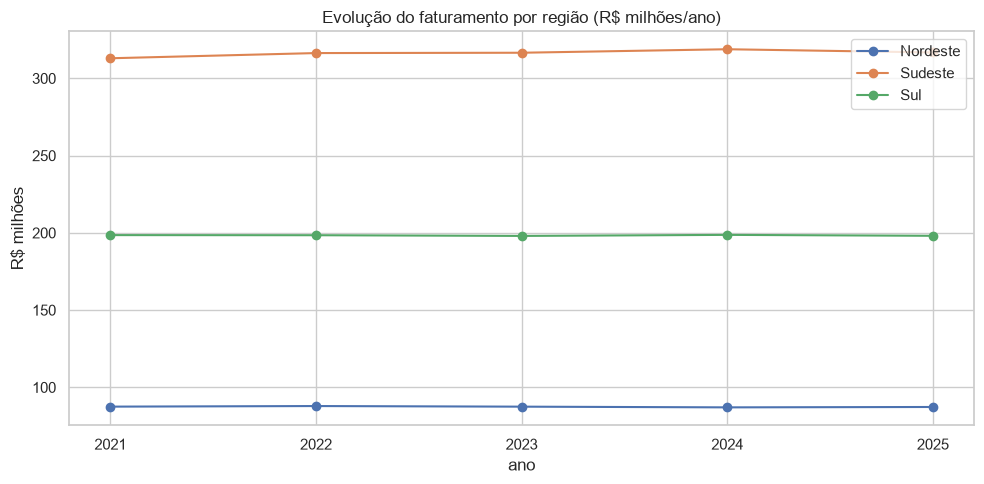

In [8]:
regiao_ano = df.dropna(subset=["macrorregiao"]).groupby(["ano", "macrorregiao"])["faturamento"].sum().unstack()

plt.figure(figsize=(10, 5))
for regiao in regiao_ano.columns:
    plt.plot(regiao_ano.index, regiao_ano[regiao] / 1e6, marker="o", label=regiao)
plt.title("Evolução do faturamento por região (R$ milhões/ano)")
plt.xlabel("ano")
plt.ylabel("R$ milhões")
plt.xticks(regiao_ano.index)
plt.legend()
plt.tight_layout()
plt.savefig("../assets/05_regiao_evolucao.png", dpi=120)
plt.show()

In [9]:
regiao_resumo = df.dropna(subset=["macrorregiao"]).groupby("macrorregiao").agg(
    faturamento_total=("faturamento", "sum"),
    ticket_medio=("faturamento", "mean"),
    volume_total=("quantidade_vendida", "sum"),
).sort_values("faturamento_total", ascending=False)
regiao_resumo

,faturamento_total,ticket_medio,volume_total
macrorregiao,,,
Sudeste,1581562340,"6,322.43",48796823
Sul,991771360,"5,841.41",30494641
Nordeste,437182015,"5,523.81",13500666


**Insight:** a distribuição regional é estável ao longo dos 5 anos, nenhuma
região cresce ou cai de forma relevante (variação de -0,3% a +1,2% entre
2021 e 2025, dentro do ruído). O Sudeste concentra o maior faturamento
absoluto (R$ 1,58 bi) e o maior ticket médio (R$ 6.322), refletindo maior
volume de clientes na região, não uma tendência de crescimento. Como não há
uma região em ascensão ou queda clara nessa base, a recomendação prática é
de alocação por concentração atual (priorizar Sudeste em logística e
estoque, já que tem mais que o dobro do volume do Nordeste), e não uma
aposta em "região emergente".

## Pergunta 5: Relação entre idade e categorias compradas

Associação, não causalidade: uso tabela de contingência normalizada por
linha (perfil de compra dentro de cada faixa etária) e o teste qui-quadrado
com V de Cramér para medir a força da associação. Qui-quadrado testa se
existe associação estatisticamente significativa; V de Cramér diz o quão
forte ela é (0 = nenhuma, 1 = perfeita). Nenhum dos dois diz que a idade
*causa* a escolha da categoria, só que as duas variáveis não são
independentes na base.

In [10]:
base_idade_cat = df.dropna(subset=["faixa_etaria", "categoria"]).copy()
# seaborn tem um bug de renderização nos rótulos do eixo quando o índice é
# categorical dtype, então converto para string antes de montar a tabela.
ordem_faixas = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
base_idade_cat["faixa_etaria"] = base_idade_cat["faixa_etaria"].astype(str)
tabela = pd.crosstab(base_idade_cat["faixa_etaria"], base_idade_cat["categoria"]).reindex(ordem_faixas)
tabela_pct = (pd.crosstab(base_idade_cat["faixa_etaria"], base_idade_cat["categoria"], normalize="index") * 100).reindex(ordem_faixas)

chi2, p_valor, gl, esperado = chi2_contingency(tabela)
n = tabela.sum().sum()
k = min(tabela.shape) - 1
cramers_v = np.sqrt((chi2 / n) / k)

print(f"qui-quadrado: {chi2:.1f}, p-valor: {p_valor:.4f}, V de Cramér: {cramers_v:.4f}")

qui-quadrado: 8.4, p-valor: 0.9893, V de Cramér: 0.0020


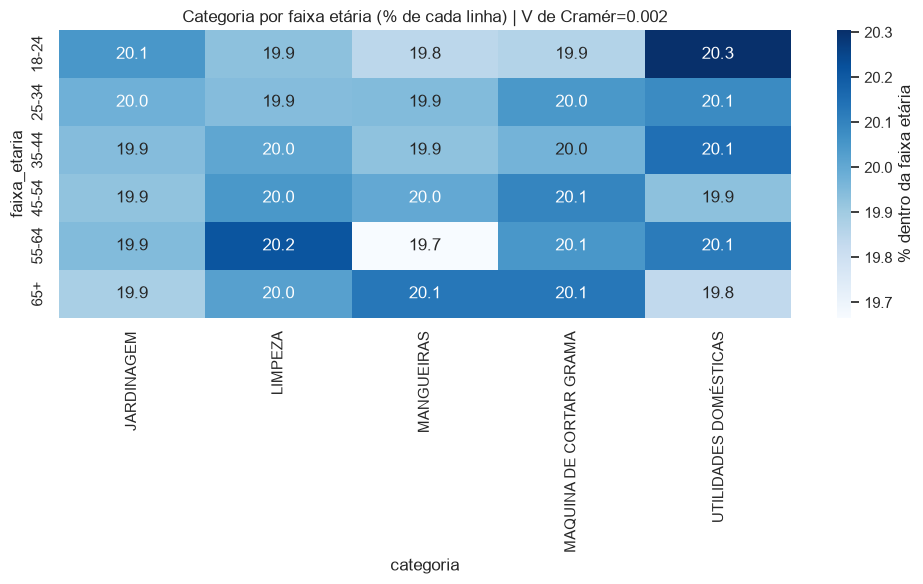

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(tabela_pct, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% dentro da faixa etária"})
plt.title(f"Categoria por faixa etária (% de cada linha) | V de Cramér={cramers_v:.3f}")
plt.tight_layout()
plt.savefig("../assets/06_idade_categoria_heatmap.png", dpi=120)
plt.show()

**Interpretação do V de Cramér:** o resultado obtido foi qui-quadrado =
8,35, p-valor = 0,989 e V de Cramér = 0,002. O p-valor alto (bem acima de
0,05) já indica que **não há evidência estatística de associação** entre
faixa etária e categoria comprada. O V de Cramér próximo de 0 confirma:
mesmo que houvesse alguma associação, ela seria desprezível. O heatmap
mostra isso visualmente, todas as faixas etárias compram as 5 categorias em
proporções quase idênticas (todas entre 19,8% e 20,3%), sem nenhuma
combinação se destacando.

Vale registrar o porquê isso importa na prática: com 500 mil linhas, é
comum que até associações fracas apareçam como "estatisticamente
significativas" só pelo tamanho da amostra. Aqui nem isso aconteceu, o
p-valor ficou alto e o V de Cramér ficou essencialmente em zero, então a
conclusão de ausência de associação é robusta, não é falta de poder
estatístico.

**Recomendações práticas:** com os dados disponíveis, **não recomendo usar
faixa etária como critério de segmentação de campanhas por categoria** para
a XYZ, os dados não sustentam essa relação. Sugiro direcionar esforço de
segmentação para variáveis que mostraram diferença real nas perguntas
anteriores (região, por concentração de volume) e, se a empresa quiser
investigar segmentação por perfil de comprador, recomendo captar dados
adicionais que não estão nessa base (renda, tamanho da residência, se tem
jardim/quintal), que fazem mais sentido de negócio pra uma loja de casa e
jardim do que idade isolada.